# Processing Strategy

## Data Characteristics
The dataset contains multiple records for the same customer across different time periods(2018 and 2019), indicating a panel data structure.
Each customer is identified by a unique ID, but appears multiple times due to yearly observations.

## Preprocessing Strategy
1) Handling Duplicate Customers
Since each customer appears multiple times, we transformed the dataset into single-record-per-customer format. To achieve this, we kept the most recent record for each customer based on the Year variable.
2) Missing values in numerical columns were imputed using the median to reduce the impact of outliers. For categorical variables, missing values were filled using the mode(most frequent value).
3) Removing Unnecessary Columns
Identifier columns such as CLIENTNUM were remeved as they do not contribute to predictive modeling. The Date_Leave column was also excluded due to its inconsistency and limited relevance to the modeling objective.
4) Final Dataset Structure
The final dataset contains one record per customer, with cleaned and consistent variables suitable for machine learning models.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url="https://raw.githubusercontent.com/shubhpatil27/credit-card-attrition-project/refs/heads/main/data/raw/credit_card.xlsx"
df = pd.read_excel(url)

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Ct,Avg_Utilization_Ratio,Quarter,Year,Date_Leave
0,712672083,Existing Customer,65,F,0,High School,Married,Less than $40K,Blue,36,...,3,2,1438.3,747,691.3,24,0.519,none,2018,"none,2018"
1,713049933,Existing Customer,47,F,1,Graduate,Married,$40K - $60K,Silver,36,...,2,2,5756.0,0,5756.0,44,0.000,none,2018,"none,2018"
2,713049933,Existing Customer,48,F,1,Graduate,Married,$40K - $60K,Silver,48,...,6,2,5756.0,990,5756.0,25,0.170,none,2019,"none,2019"
3,713135883,Existing Customer,65,F,0,College,Married,Less than $40K,Blue,65,...,5,0,4315.0,393,3598.0,73,0.090,none,2019,"none,2019"
4,713135883,Existing Customer,64,F,0,College,Married,Less than $40K,Blue,53,...,3,0,4315.0,717,3598.0,51,0.166,none,2018,"none,2018"


# 1. Duplicate customers

In [2]:
# how many total rows and unique customers
print("Total rows:", len(df))
print("Unique customers:", df["CLIENTNUM"].nunique())

# customers that appear more than once
duplicate_counts = df["CLIENTNUM"].value_counts()
duplicate_customers = duplicate_counts[duplicate_counts > 1]

print("Number of customers with duplicate records:", len(duplicate_customers))
duplicate_customers.head(10)

Total rows: 20071
Unique customers: 11571
Number of customers with duplicate records: 8500


,count
CLIENTNUM,
822051858,2
820288233,2
820075983,2
718693683,2
718589133,2
718476033,2
718181433,2
717965808,2
717914808,2


* Observation: The dataset contains repeated customer IDs, which means some customers appear multiple times across different years.
* Interpretation:
This indicates a panel structure rather than a single-record-per-customer dataset.

# 2. Missing values

In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_percent
})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent", ascending=False)


,missing_count,missing_percent


No missing values were found in the dataset, indicating that the data is complete and does not require imputation.

# 3. Outliers

Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Year'],
      dtype='object')


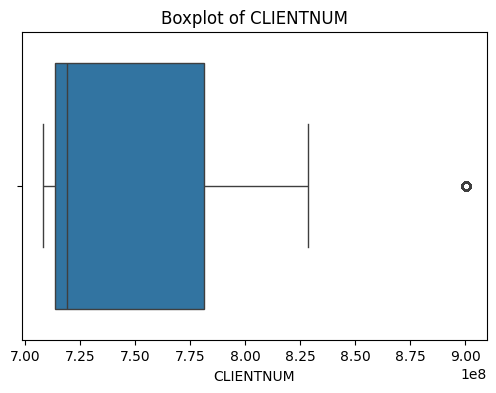

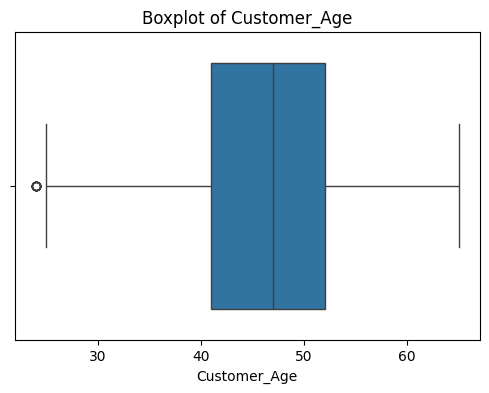

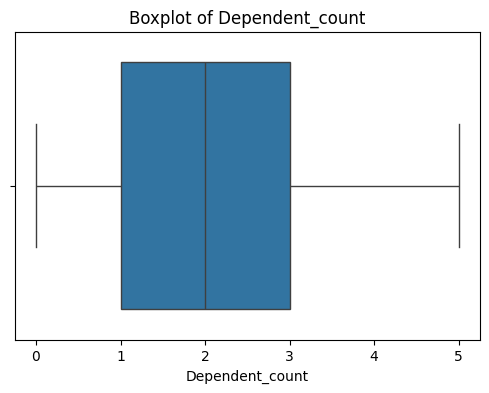

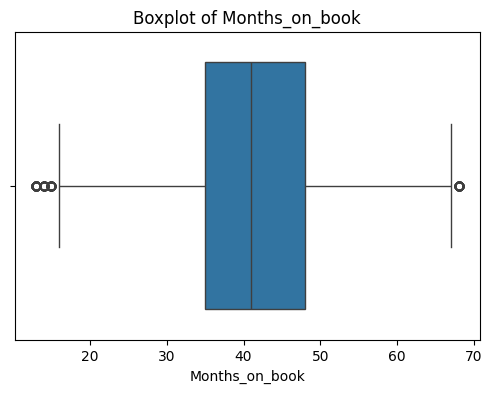

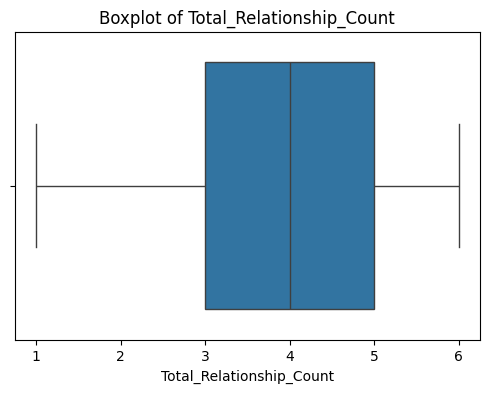

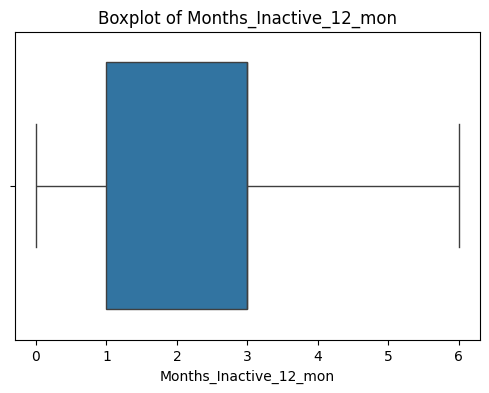

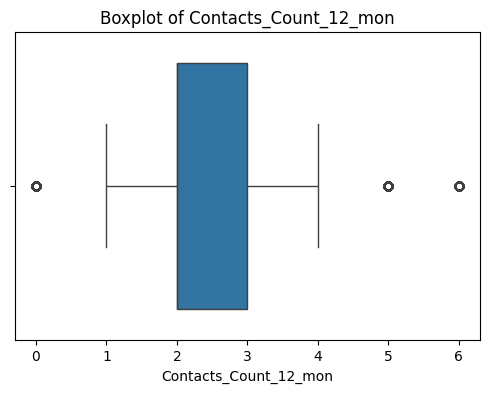

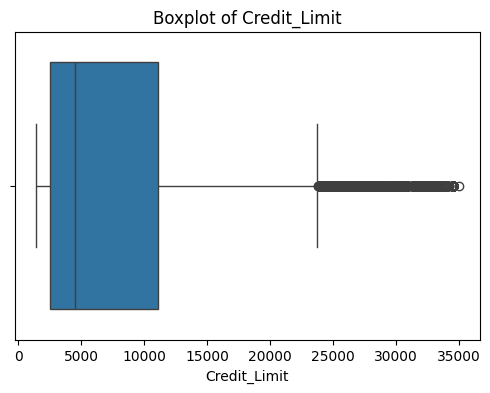

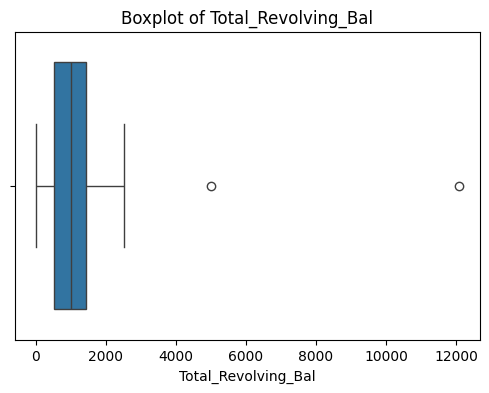

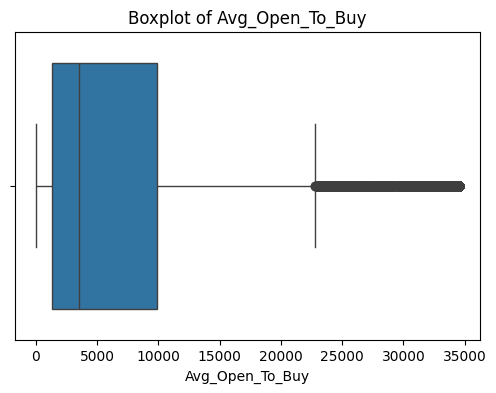

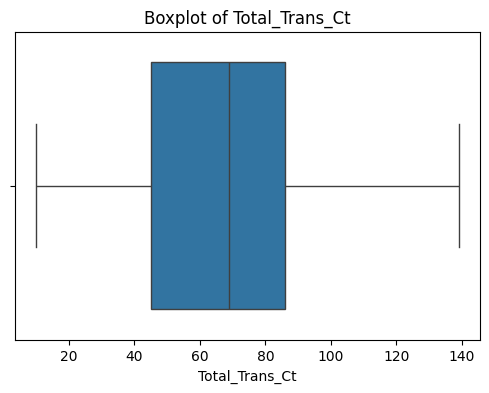

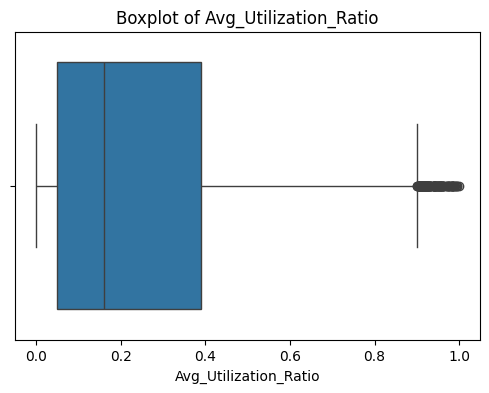

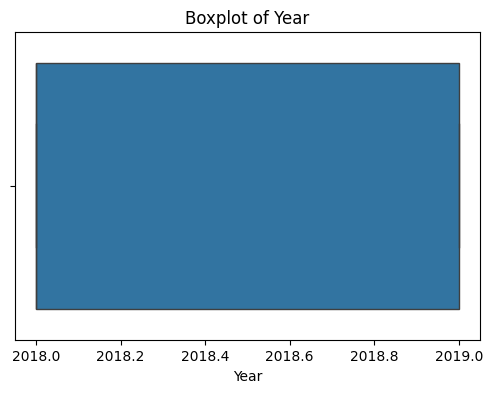

In [8]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(numeric_cols)

key_numeric_cols = ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Year']

for col in key_numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [9]:
outlier_summary = {}

for col in key_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

pd.Series(outlier_summary).sort_values(ascending=False)

,0
Credit_Limit,1952
Avg_Open_To_Buy,1895
CLIENTNUM,1444
Contacts_Count_12_mon,1239
Months_on_book,295
Avg_Utilization_Ratio,114
Customer_Age,10
Total_Revolving_Bal,2
Dependent_count,0
Total_Relationship_Count,0




*   Observation:
Several numerical variables, such as Credit Limit and Avg Open To Buy, show a large number of extreme values.
*  Interpretation:
“These values likely reflect genuine differences in customer financial profiles rather than data errors.
* Decision:
Therefore, no outlier removal was performed to preserve important information.


# 4. Unnecessary columns

In [10]:
df.columns.tolist()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Trans_Ct',
 'Avg_Utilization_Ratio',
 'Quarter',
 'Year',
 'Date_Leave']

In [11]:
df[["CLIENTNUM","Date_Leave"]].head()

,CLIENTNUM,Date_Leave
0,712672083,"none,2018"
1,713049933,"none,2018"
2,713049933,"none,2019"
3,713135883,"none,2019"
4,713135883,"none,2018"


* Decision:
Therefore, no outlier removal was performed to preserve important information.
* Observation:
Some columns, such as customer identifiers and irregular date-related fields, may not contribute meaningful predictive information.

# 5. Preprocessing

In [12]:

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ------------------------
    # 1. Sort by latest year
    # ------------------------
    df = df.sort_values(by=['CLIENTNUM', 'Year'], ascending=[True, False])

    # ------------------------
    # 2. Keep latest record per customer
    # ------------------------
    df = df.drop_duplicates(subset='CLIENTNUM', keep='first')

    # ------------------------
    # 3. Drop unnecessary columns
    # ------------------------
    if 'CLIENTNUM' in df.columns:
        df = df.drop(columns=['CLIENTNUM'])

    if 'Date_Leave' in df.columns:
        df = df.drop(columns=['Date_Leave'])

    return df

In [14]:
cleaned_df = clean_data(df)

print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)

cleaned_df.head()

Original shape: (20071, 21)
Cleaned shape: (11571, 19)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Ct,Avg_Utilization_Ratio,Quarter,Year
10096,Existing Customer,46,F,3,High School,Married,$40K - $60K,Blue,48,4,2,3,3544.0,943,1883.0,44,0.270,none,2019
1776,Attrited Customer,58,M,0,College,Single,$40K - $60K,Blue,45,3,1,3,3421.0,2517,904.0,21,0.736,Q4,2018
1205,Attrited Customer,60,M,3,Graduate,Divorced,$60K - $80K,Silver,38,6,3,3,8258.0,1771,6487.0,23,0.214,Q2,2018
17872,Attrited Customer,35,F,2,Uneducated,Single,Less than $40K,Blue,36,6,2,2,1500.0,784,1438.3,47,0.520,Q4,2019
6446,Existing Customer,50,F,2,High School,Married,Less than $40K,Blue,53,3,1,2,3128.0,232,2379.0,80,0.070,none,2019


* Observation
The dataset contains multiple records per customer across different years, indicating a panel data structure.
* Decision
To simplify the modeling process, we retained only the most recent record for each customer based on the Year variable.
* Result
This transformation ensures that each customer is represented by a single observation, making the dataset suitable for predictive modeling.

# 6. Feature engineering

In [15]:
import numpy as np

def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Average transaction amount per transaction
    if {'Total_Revolving_Bal', 'Total_Trans_Ct'}.issubset(df.columns):
        df['avg_revolving_per_trans'] = df['Total_Revolving_Bal'] / (df['Total_Trans_Ct'] + 1)

    # 2. Inactivity flag
    if 'Months_Inactive_12_mon' in df.columns:
        df['is_inactive'] = (df['Months_Inactive_12_mon'] >= 3).astype(int)

    # 3. Low activity flag
    if 'Total_Trans_Ct' in df.columns:
        df['low_activity'] = (df['Total_Trans_Ct'] < 50).astype(int)

    # 4. Low utilization flag
    if 'Avg_Utilization_Ratio' in df.columns:
        df['low_utilization'] = (df['Avg_Utilization_Ratio'] < 0.2).astype(int)

    # 5. Contact frequency flag
    if 'Contacts_Count_12_mon' in df.columns:
        df['high_contact_count'] = (df['Contacts_Count_12_mon'] >= 4).astype(int)

    # 6. Available credit ratio
    if {'Avg_Open_To_Buy', 'Credit_Limit'}.issubset(df.columns):
        df['open_to_buy_ratio'] = df['Avg_Open_To_Buy'] / (df['Credit_Limit'] + 1)

    # 7. Log transform for skewed financial variable
    if 'Credit_Limit' in df.columns:
        df['log_credit_limit'] = np.log1p(df['Credit_Limit'])

    return df

In [16]:
feature_df = create_features(cleaned_df)

print("Cleaned shape:", cleaned_df.shape)
print("Feature shape:", feature_df.shape)
feature_df.head()

Cleaned shape: (11571, 19)
Feature shape: (11571, 26)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Avg_Utilization_Ratio,Quarter,Year,avg_revolving_per_trans,is_inactive,low_activity,low_utilization,high_contact_count,open_to_buy_ratio,log_credit_limit
10096,Existing Customer,46,F,3,High School,Married,$40K - $60K,Blue,48,4,...,0.270,none,2019,20.955556,0,1,0,0,0.531171,8.173293
1776,Attrited Customer,58,M,0,College,Single,$40K - $60K,Blue,45,3,...,0.736,Q4,2018,114.409091,0,1,0,0,0.264173,8.137980
1205,Attrited Customer,60,M,3,Graduate,Divorced,$60K - $80K,Silver,38,6,...,0.214,Q2,2018,73.791667,1,1,0,0,0.785446,9.019059
17872,Attrited Customer,35,F,2,Uneducated,Single,Less than $40K,Blue,36,6,...,0.520,Q4,2019,16.333333,0,1,0,0,0.958228,7.313887
6446,Existing Customer,50,F,2,High School,Married,Less than $40K,Blue,53,3,...,0.070,none,2019,2.864198,0,0,1,0,0.760307,8.048469


Based on exploratory data analysis, we created new features to capture customer engagement patterns, including transaction activity, inactivity levels, and credit utilization.
These engineered features help the model better identify behavioral pattern associated with customer attrition.

In [17]:
feature_df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Quarter',
       'Year', 'avg_revolving_per_trans', 'is_inactive', 'low_activity',
       'low_utilization', 'high_contact_count', 'open_to_buy_ratio',
       'log_credit_limit'],
      dtype='object')